<a href="https://colab.research.google.com/github/Vyshnavi-kommu/predictive_analytics/blob/credit-card-fraud/credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Confusion Matrix:
[[5688    0]
 [   0    9]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      5688
           1     1.0000    1.0000    1.0000         9

    accuracy                         1.0000      5697
   macro avg     1.0000    1.0000    1.0000      5697
weighted avg     1.0000    1.0000    1.0000      5697



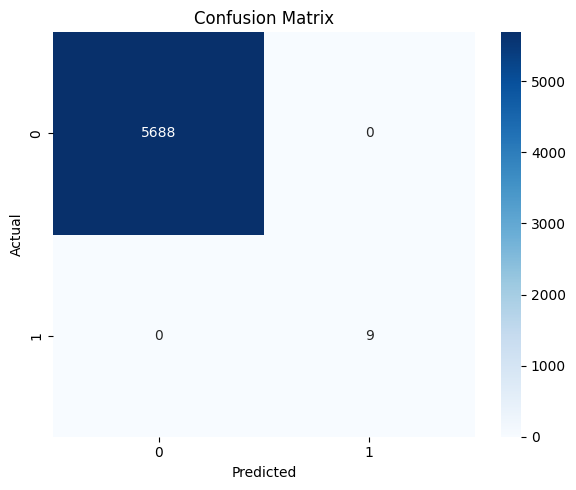

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset (use only a 10% sample for speed)
df = pd.read_csv("creditcard.csv").sample(frac=0.1, random_state=42)

# Feature scaling for 'Amount'
df['Amount'] = StandardScaler().fit_transform(df[['Amount']])

# Drop 'Time' column
df.drop(['Time'], axis=1, inplace=True)

# Define features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Optimized Random Forest
model = RandomForestClassifier(
    n_estimators=50,      # Fewer trees
    max_depth=10,         # Limit tree depth
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
